In [3]:
# ============================================================
# STEP 1 — PREPROCESSING ENVIRONMENT SETUP
# ============================================================

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torchvision
from torchvision import transforms

print("Preprocessing environment ready")
print("Python executable:", os.sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

Preprocessing environment ready
Python executable: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu


In [3]:
# ============================================================
# STEP 2 — DATASET PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "GroceryStoreDataset-master"
    / "dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

CLASSES_CSV = DATASET_ROOT / "classes.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)

print("\nChecking dataset paths...")

for name, path in {
    "Train": TRAIN_DIR,
    "Validation": VAL_DIR,
    "Test": TEST_DIR,
    "Classes CSV": CLASSES_CSV,
}.items():
    print(f"{'OK' if path.exists() else 'MISSING':8} {name}: {path}")

Project root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
Dataset root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking dataset paths...
OK       Train: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train
OK       Validation: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val
OK       Test: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test
OK       Classes CSV: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv


#Load the class metadata

In [4]:
# ============================================================
# STEP 3 — LOAD CLASS METADATA
# ============================================================

classes_df = pd.read_csv(CLASSES_CSV)

print("Classes CSV loaded successfully")
print("Shape:", classes_df.shape)

print("\nColumns:")
print(classes_df.columns.tolist())

print("\nFirst 10 classes:")
display(
    classes_df[
        [
            "Class Name (str)",
            "Class ID (int)",
            "Coarse Class Name (str)",
            "Coarse Class ID (int)"
        ]
    ].head(10)
)

# Basic validation
assert classes_df["Class ID (int)"].nunique() == 81
assert classes_df["Class ID (int)"].min() == 0
assert classes_df["Class ID (int)"].max() == 80

print("\nFine-grained classes:", classes_df["Class ID (int)"].nunique())
print(
    "Coarse-grained categories:",
    classes_df["Coarse Class ID (int)"].nunique()
)
print("Class metadata validation: PASSED")

Classes CSV loaded successfully
Shape: (81, 6)

Columns:
['Class Name (str)', 'Class ID (int)', 'Coarse Class Name (str)', 'Coarse Class ID (int)', 'Iconic Image Path (str)', 'Product Description Path (str)']

First 10 classes:


,Class Name (str),Class ID (int),Coarse Class Name (str),Coarse Class ID (int)
0,Golden-Delicious,0,Apple,0
1,Granny-Smith,1,Apple,0
2,Pink-Lady,2,Apple,0
3,Red-Delicious,3,Apple,0
4,Royal-Gala,4,Apple,0
5,Avocado,5,Avocado,1
6,Banana,6,Banana,2
7,Kiwi,7,Kiwi,3
8,Lemon,8,Lemon,4
9,Lime,9,Lime,5



Fine-grained classes: 81
Coarse-grained categories: 43
Class metadata validation: PASSED


#Load train, validation, and test labels

In [5]:
# ============================================================
# STEP 4 — LOAD DATASET LABEL FILES
# ============================================================

LABEL_COLUMNS = [
    "image_path",
    "fine_class_id",
    "coarse_class_id"
]

train_df = pd.read_csv(
    DATASET_ROOT / "train.txt",
    header=None,
    names=LABEL_COLUMNS
)

val_df = pd.read_csv(
    DATASET_ROOT / "val.txt",
    header=None,
    names=LABEL_COLUMNS
)

test_df = pd.read_csv(
    DATASET_ROOT / "test.txt",
    header=None,
    names=LABEL_COLUMNS
)

print("Dataset label files loaded successfully\n")

print("Train      :", train_df.shape)
print("Validation :", val_df.shape)
print("Test       :", test_df.shape)

print("\nTotal images:",
      len(train_df) + len(val_df) + len(test_df))

print("\nTrain sample:")
display(train_df.head())

print("\nValidation sample:")
display(val_df.head())

print("\nTest sample:")
display(test_df.head())

Dataset label files loaded successfully

Train      : (2640, 3)
Validation : (296, 3)
Test       : (2485, 3)

Total images: 5421

Train sample:


,image_path,fine_class_id,coarse_class_id
0,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
1,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
2,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
3,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0
4,train/Fruit/Apple/Golden-Delicious/Golden-Deli...,0,0



Validation sample:


,image_path,fine_class_id,coarse_class_id
0,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
1,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
2,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
3,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0
4,val/Fruit/Apple/Golden-Delicious/Golden-Delici...,0,0



Test sample:


,image_path,fine_class_id,coarse_class_id
0,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
1,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
2,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
3,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0
4,test/Fruit/Apple/Golden-Delicious/Golden-Delic...,0,0


Verify label consistency

In [6]:
# ============================================================
# STEP 5 — LABEL CONSISTENCY VALIDATION
# ============================================================

print("=" * 70)
print("LABEL CONSISTENCY VALIDATION")
print("=" * 70)

# Create fine → coarse mapping from classes.csv
fine_to_coarse = dict(
    zip(
        classes_df["Class ID (int)"],
        classes_df["Coarse Class ID (int)"]
    )
)

for split_name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    
    # Check fine-class IDs
    invalid_fine = ~df["fine_class_id"].isin(
        classes_df["Class ID (int)"]
    )
    
    # Check coarse-class IDs
    invalid_coarse = ~df["coarse_class_id"].isin(
        classes_df["Coarse Class ID (int)"]
    )
    
    # Check fine → coarse relationship
    mapping_errors = df.apply(
        lambda row: fine_to_coarse.get(row["fine_class_id"])
        != row["coarse_class_id"],
        axis=1
    )
    
    print(f"\n{split_name}")
    print("-" * 70)
    print("Invalid fine-class IDs   :", invalid_fine.sum())
    print("Invalid coarse-class IDs :", invalid_coarse.sum())
    print("Fine → coarse errors     :", mapping_errors.sum())

print("\n" + "=" * 70)
print("LABEL VALIDATION COMPLETED")
print("=" * 70)

LABEL CONSISTENCY VALIDATION

Train
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Validation
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

Test
----------------------------------------------------------------------
Invalid fine-class IDs   : 0
Invalid coarse-class IDs : 0
Fine → coarse errors     : 0

LABEL VALIDATION COMPLETED


Inspect actual training images


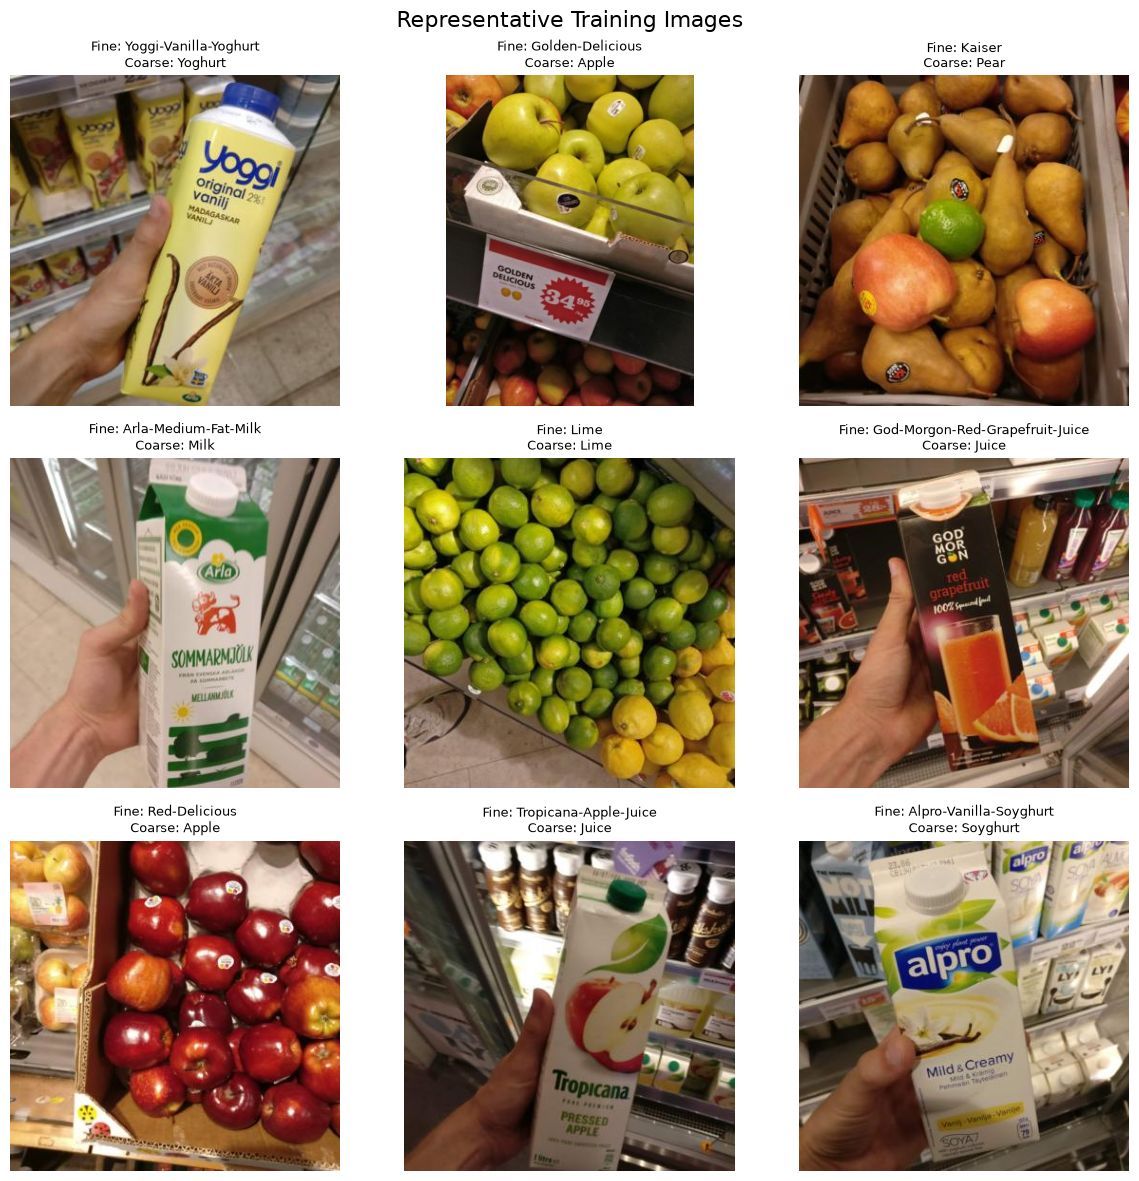

In [8]:
# ============================================================
# STEP 6 — VISUAL INSPECTION OF TRAINING IMAGES
# ============================================================

# Select 9 representative training samples
sample_df = train_df.sample(
    n=9,
    random_state=42
).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):

    # image_path already contains "train/..."
    image_path = DATASET_ROOT / row["image_path"]

    image = Image.open(image_path).convert("RGB")

    fine_id = int(row["fine_class_id"])
    coarse_id = int(row["coarse_class_id"])

    fine_name = classes_df.loc[
        classes_df["Class ID (int)"] == fine_id,
        "Class Name (str)"
    ].iloc[0]

    coarse_name = classes_df.loc[
        classes_df["Coarse Class ID (int)"] == coarse_id,
        "Coarse Class Name (str)"
    ].iloc[0]

    ax.imshow(image)
    ax.set_title(
        f"Fine: {fine_name}\nCoarse: {coarse_name}",
        fontsize=9
    )
    ax.axis("off")

plt.suptitle(
    "Representative Training Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

STEP 3: Define preprocessing and augmentation

In [9]:
# ============================================================
# STEP 1 — IMPORTS AND ENVIRONMENT
# ============================================================

from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("Preprocessing notebook initialized")
print("Python executable:", sys.executable)
print("PyTorch:", torch.__version__)

Preprocessing notebook initialized
Python executable: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu


In [10]:
# ============================================================
# STEP 2 — DATASET PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "GroceryStoreDataset-master"
    / "dataset"
)

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

CLASSES_CSV = DATASET_ROOT / "classes.csv"

print("Project root :", PROJECT_ROOT)
print("Dataset root :", DATASET_ROOT)

print("\nChecking dataset paths...")

assert DATASET_ROOT.exists(), "Dataset root not found"
assert TRAIN_DIR.exists(), "Training directory not found"
assert VAL_DIR.exists(), "Validation directory not found"
assert TEST_DIR.exists(), "Test directory not found"
assert CLASSES_CSV.exists(), "classes.csv not found"

print("Train      :", TRAIN_DIR, "OK")
print("Validation :", VAL_DIR, "OK")
print("Test       :", TEST_DIR, "OK")
print("Classes CSV:", CLASSES_CSV, "OK")

Project root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification
Dataset root : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset

Checking dataset paths...
Train      : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train OK
Validation : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\val OK
Test       : c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\test OK
Classes CSV: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\classes.csv OK


In [17]:
# ============================================================
# STEP 3 — IMAGE PREPROCESSING AND AUGMENTATION
# ============================================================

IMAGE_SIZE = 224

# ImageNet normalization
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(
    degrees=10,
    fill=(128, 128, 128)
),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15,
        hue=0.03
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation transformations
# ------------------------------------------------------------

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Test transformations
# ------------------------------------------------------------

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


print("Image preprocessing configured successfully")
print("Target image size:", IMAGE_SIZE, "x", IMAGE_SIZE)

print("\nTraining transformations:")
print(train_transform)

print("\nValidation transformations:")
print(val_transform)

print("\nTest transformations:")
print(test_transform)

Image preprocessing configured successfully
Target image size: 224 x 224

Training transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=(128, 128, 128))
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=(-0.03, 0.03))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Test transformations:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [18]:
# ============================================================
# STEP 4 — TEST PREPROCESSING ON A REAL IMAGE
# ============================================================

# Get one image from the training directory
sample_image_path = next(TRAIN_DIR.rglob("*.jpg"))

print("Sample image:")
print(sample_image_path)

# Open original image
original_image = Image.open(sample_image_path).convert("RGB")

# Apply training preprocessing
processed_image = train_transform(original_image)

print("\nOriginal size :", original_image.size)
print("Processed size:", tuple(processed_image.shape))
print("Processed dtype:", processed_image.dtype)

Sample image:
c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\dataset\GroceryStoreDataset-master\dataset\train\Vegetables\Asparagus\Asparagus_001.jpg

Original size : (348, 464)
Processed size: (3, 224, 224)
Processed dtype: torch.float32


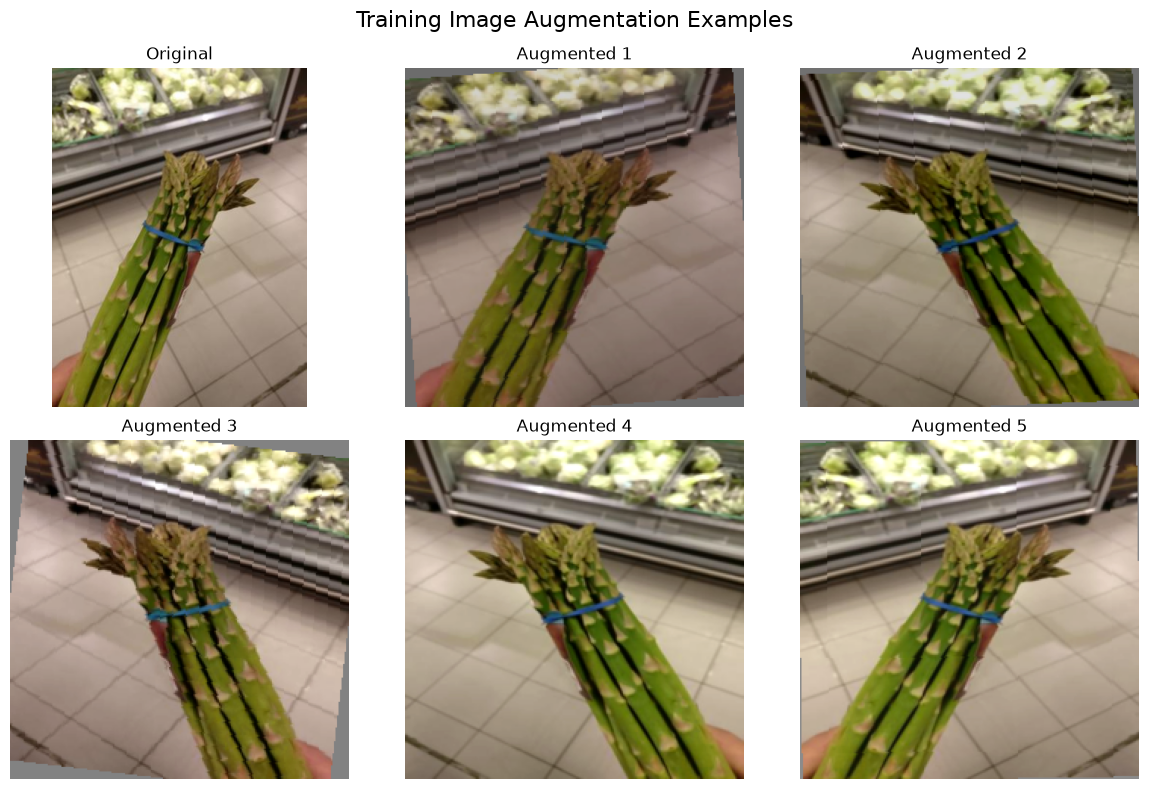

In [19]:
# ============================================================
# STEP 5 — VISUALIZE AUGMENTATION
# ============================================================

def denormalize(tensor):
    """
    Convert a normalized tensor back to displayable RGB values.
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    image = tensor * std + mean
    image = torch.clamp(image, 0, 1)

    return image


fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Generate augmented versions
for i in range(5):
    augmented = train_transform(original_image)
    display_image = denormalize(augmented)
    display_image = display_image.permute(1, 2, 0).numpy()

    ax = axes.flat[i + 1]
    ax.imshow(display_image)
    ax.set_title(f"Augmented {i + 1}")
    ax.axis("off")

plt.suptitle(
    "Training Image Augmentation Examples",
    fontsize=16
)

plt.tight_layout()
plt.show()

STEP 4 — DATASET AND DATALOADERS

In [20]:
# ============================================================
# STEP 4 — PYTORCH DATASET AND DATALOADER PREPARATION
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path
import torch

print("PyTorch Dataset/DataLoader imports successful")
print("PyTorch version:", torch.__version__)

PyTorch Dataset/DataLoader imports successful
PyTorch version: 2.14.0+cpu


In [21]:
# ============================================================
# STEP 4 — CELL 2
# CUSTOM GROCERY DATASET
# ============================================================

class GroceryProductDataset(Dataset):

    def __init__(self, dataframe, dataset_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Full image path
        image_path = self.dataset_root / row["image_path"]

        # Load image and ensure RGB format
        image = Image.open(image_path).convert("RGB")

        # Apply preprocessing / augmentation
        if self.transform is not None:
            image = self.transform(image)

        # Fine-grained class label
        fine_label = int(row["fine_class_id"])

        # Coarse-grained category label
        coarse_label = int(row["coarse_class_id"])

        return image, fine_label, coarse_label


print("GroceryProductDataset class created successfully")

GroceryProductDataset class created successfully


In [22]:
# ============================================================
# STEP 4 — CELL 3
# CREATE TRAIN / VALIDATION / TEST DATASETS
# ============================================================

train_dataset = GroceryProductDataset(
    dataframe=train_df,
    dataset_root=DATASET_ROOT,
    transform=train_transform
)

val_dataset = GroceryProductDataset(
    dataframe=val_df,
    dataset_root=DATASET_ROOT,
    transform=val_transform
)

test_dataset = GroceryProductDataset(
    dataframe=test_df,
    dataset_root=DATASET_ROOT,
    transform=test_transform
)

print("Dataset objects created successfully")
print("------------------------------------")
print("Training dataset   :", len(train_dataset))
print("Validation dataset :", len(val_dataset))
print("Test dataset       :", len(test_dataset))

Dataset objects created successfully
------------------------------------
Training dataset   : 2640
Validation dataset : 296
Test dataset       : 2485


In [23]:
# ============================================================
# STEP 4 — CELL 4
# VERIFY A SINGLE DATASET SAMPLE
# ============================================================

sample_image, sample_fine_label, sample_coarse_label = train_dataset[0]

print("Single dataset sample loaded successfully")
print("------------------------------------------")
print("Image type        :", type(sample_image))
print("Image shape       :", sample_image.shape)
print("Image dtype       :", sample_image.dtype)
print("Fine class ID     :", sample_fine_label)
print("Coarse class ID   :", sample_coarse_label)
print("Image value range :", 
      f"{sample_image.min().item():.4f} to {sample_image.max().item():.4f}")

Single dataset sample loaded successfully
------------------------------------------
Image type        : <class 'torch.Tensor'>
Image shape       : torch.Size([3, 224, 224])
Image dtype       : torch.float32
Fine class ID     : 0
Coarse class ID   : 0
Image value range : -2.1179 to 1.5982


In [24]:
# ============================================================
# STEP 4 — CELL 5
# CREATE TRAIN / VALIDATION / TEST DATALOADERS
# ============================================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully")
print("---------------------------------")
print("Batch size        :", BATCH_SIZE)
print("Training batches  :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches      :", len(test_loader))

DataLoaders created successfully
---------------------------------
Batch size        : 32
Training batches  : 83
Validation batches: 10
Test batches      : 78


In [25]:
# ============================================================
# STEP 4 — CELL 6
# VERIFY ONE COMPLETE TRAINING BATCH
# ============================================================

images, fine_labels, coarse_labels = next(iter(train_loader))

print("Training batch loaded successfully")
print("-----------------------------------")
print("Images shape       :", images.shape)
print("Images dtype       :", images.dtype)
print("Fine labels shape  :", fine_labels.shape)
print("Fine labels dtype  :", fine_labels.dtype)
print("Coarse labels shape:", coarse_labels.shape)
print("Coarse labels dtype:", coarse_labels.dtype)

print("\nFirst 10 fine labels:")
print(fine_labels[:10].tolist())

print("\nFirst 10 coarse labels:")
print(coarse_labels[:10].tolist())

Training batch loaded successfully
-----------------------------------
Images shape       : torch.Size([32, 3, 224, 224])
Images dtype       : torch.float32
Fine labels shape  : torch.Size([32])
Fine labels dtype  : torch.int64
Coarse labels shape: torch.Size([32])
Coarse labels dtype: torch.int64

First 10 fine labels:
[56, 20, 77, 27, 62, 66, 36, 79, 3, 27]

First 10 coarse labels:
[27, 13, 41, 18, 31, 35, 19, 41, 0, 18]


In [26]:
# ============================================================
# STEP 4 — CELL 7
# FINAL DATALOADER SANITY CHECK
# ============================================================

def check_loader(loader, loader_name):
    images, fine_labels, coarse_labels = next(iter(loader))

    print(f"{loader_name}")
    print("-" * 50)
    print("Batch image shape :", tuple(images.shape))
    print("Fine labels shape :", tuple(fine_labels.shape))
    print("Coarse labels shape:", tuple(coarse_labels.shape))
    print("Image dtype       :", images.dtype)
    print("Fine label dtype  :", fine_labels.dtype)
    print("Coarse label dtype:", coarse_labels.dtype)
    print()


check_loader(train_loader, "TRAINING")
check_loader(val_loader, "VALIDATION")
check_loader(test_loader, "TEST")

print("FINAL DATALOADER SANITY CHECK PASSED")

TRAINING
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

VALIDATION
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

TEST
--------------------------------------------------
Batch image shape : (32, 3, 224, 224)
Fine labels shape : (32,)
Coarse labels shape: (32,)
Image dtype       : torch.float32
Fine label dtype  : torch.int64
Coarse label dtype: torch.int64

FINAL DATALOADER SANITY CHECK PASSED


STEP 5 — MODEL ARCHITECTURE

In [27]:
# ============================================================
# STEP 5 — MODEL ARCHITECTURE
# CELL 1 — MODEL CONFIGURATION
# ============================================================

NUM_CLASSES = 81
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Model configuration")
print("-------------------")
print("Number of fine-grained classes:", NUM_CLASSES)
print("Training device:", DEVICE)

Model configuration
-------------------
Number of fine-grained classes: 81
Training device: cpu


In [28]:
# ============================================================
# STEP 5 — CELL 2
# LOAD PRETRAINED RESNET-50
# ============================================================

from torchvision.models import resnet50, ResNet50_Weights

# Load ImageNet-pretrained ResNet-50
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print("Pretrained ResNet-50 loaded successfully")
print("-----------------------------------------")
print("Original output classes:", model.fc.out_features)
print("Model type:", type(model).__name__)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100.0%


Pretrained ResNet-50 loaded successfully
-----------------------------------------
Original output classes: 1000
Model type: ResNet


In [29]:
# ============================================================
# STEP 5 — CELL 3
# MODIFY RESNET-50 FOR 81 PRODUCT CLASSES
# ============================================================

import torch.nn as nn

# Get the number of input features to the original classifier
num_features = model.fc.in_features

# Replace the original ImageNet classifier
model.fc = nn.Linear(
    in_features=num_features,
    out_features=NUM_CLASSES
)

# Move model to the selected device
model = model.to(DEVICE)

print("ResNet-50 classification layer modified successfully")
print("-----------------------------------------------------")
print("Classifier input features :", num_features)
print("Classifier output classes:", model.fc.out_features)
print("Model device              :", DEVICE)
print("Final classifier          :", model.fc)

ResNet-50 classification layer modified successfully
-----------------------------------------------------
Classifier input features : 2048
Classifier output classes: 81
Model device              : cpu
Final classifier          : Linear(in_features=2048, out_features=81, bias=True)


In [30]:
# ============================================================
# STEP 5 — CELL 4
# INSPECT MODEL PARAMETERS
# ============================================================

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("MODEL PARAMETER SUMMARY")
print("=" * 60)
print("Total parameters     :", f"{total_parameters:,}")
print("Trainable parameters :", f"{trainable_parameters:,}")
print("Frozen parameters    :", f"{total_parameters - trainable_parameters:,}")

print("\nFinal classifier:")
print(model.fc)

MODEL PARAMETER SUMMARY
Total parameters     : 23,674,001
Trainable parameters : 23,674,001
Frozen parameters    : 0

Final classifier:
Linear(in_features=2048, out_features=81, bias=True)


In [31]:
# ============================================================
# STEP 5 — CELL 5
# FREEZE RESNET-50 BACKBONE
# ============================================================

# Freeze all model parameters
for parameter in model.parameters():
    parameter.requires_grad = False

# Keep the new classification layer trainable
for parameter in model.fc.parameters():
    parameter.requires_grad = True


# Count parameters after freezing
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

frozen_parameters = total_parameters - trainable_parameters


print("TRANSFER LEARNING FREEZING CONFIGURED")
print("=" * 60)
print("Total parameters     :", f"{total_parameters:,}")
print("Trainable parameters :", f"{trainable_parameters:,}")
print("Frozen parameters    :", f"{frozen_parameters:,}")

print("\nTrainable layer:")
print("model.fc")
print(model.fc)

TRANSFER LEARNING FREEZING CONFIGURED
Total parameters     : 23,674,001
Trainable parameters : 165,969
Frozen parameters    : 23,508,032

Trainable layer:
model.fc
Linear(in_features=2048, out_features=81, bias=True)


In [32]:
# ============================================================
# STEP 5 — CELL 6
# VERIFY PARAMETER FREEZING
# ============================================================

print("TRAINABLE PARAMETERS")
print("=" * 60)

trainable_layers = []

for name, parameter in model.named_parameters():
    if parameter.requires_grad:
        trainable_layers.append(name)
        print(name)

print("\nTotal trainable parameter tensors:", len(trainable_layers))

# Verify that every trainable parameter belongs to the classifier
only_classifier_trainable = all(
    name.startswith("fc.")
    for name in trainable_layers
)

print("\nOnly classifier is trainable:", only_classifier_trainable)

# Verify that the backbone is frozen
backbone_frozen = all(
    not parameter.requires_grad
    for name, parameter in model.named_parameters()
    if not name.startswith("fc.")
)

print("Backbone is completely frozen:", backbone_frozen)

if only_classifier_trainable and backbone_frozen:
    print("\nPARAMETER FREEZING CHECK PASSED")
else:
    print("\nPARAMETER FREEZING CHECK FAILED")

TRAINABLE PARAMETERS
fc.weight
fc.bias

Total trainable parameter tensors: 2

Only classifier is trainable: True
Backbone is completely frozen: True

PARAMETER FREEZING CHECK PASSED


In [33]:
# ============================================================
# STEP 5 — CELL 7
# FORWARD-PASS SANITY CHECK
# ============================================================

# Get one batch from the training DataLoader
images, fine_labels, coarse_labels = next(iter(train_loader))

# Move images to the selected device
images = images.to(DEVICE)

# Evaluation mode for this technical check
model.eval()

# Disable gradient calculation
with torch.no_grad():
    outputs = model(images)

print("FORWARD-PASS SANITY CHECK")
print("=" * 60)
print("Input shape        :", tuple(images.shape))
print("Output shape       :", tuple(outputs.shape))
print("Output dtype       :", outputs.dtype)
print("Expected classes   :", NUM_CLASSES)

# Verify output dimensions
expected_shape = (images.shape[0], NUM_CLASSES)

print("\nExpected output shape:", expected_shape)
print("Actual output shape  :", tuple(outputs.shape))

if tuple(outputs.shape) == expected_shape:
    print("\nFORWARD-PASS CHECK PASSED")
else:
    print("\nFORWARD-PASS CHECK FAILED")

FORWARD-PASS SANITY CHECK
Input shape        : (32, 3, 224, 224)
Output shape       : (32, 81)
Output dtype       : torch.float32
Expected classes   : 81

Expected output shape: (32, 81)
Actual output shape  : (32, 81)

FORWARD-PASS CHECK PASSED


In [34]:
# ============================================================
# STEP 5 — CELL 8
# CLASSIFICATION LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss()

# Use the previously generated batch
# Model is already in evaluation mode from the forward-pass test

with torch.no_grad():
    loss = criterion(outputs, fine_labels.to(DEVICE))

print("LOSS FUNCTION CONFIGURED")
print("=" * 60)
print("Loss function:", criterion)
print("Model output shape:", tuple(outputs.shape))
print("Fine-label shape:", tuple(fine_labels.shape))
print("Initial batch loss:", f"{loss.item():.6f}")

if torch.isfinite(loss):
    print("\nLOSS SANITY CHECK PASSED")
else:
    print("\nLOSS SANITY CHECK FAILED")

LOSS FUNCTION CONFIGURED
Loss function: CrossEntropyLoss()
Model output shape: (32, 81)
Fine-label shape: (32,)
Initial batch loss: 4.361836

LOSS SANITY CHECK PASSED


In [35]:
# ============================================================
# STEP 5 — CELL 9
# OPTIMIZER CONFIGURATION
# ============================================================

LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4

optimizer = torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print("OPTIMIZER CONFIGURED")
print("=" * 60)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", LEARNING_RATE)
print("Weight decay  :", WEIGHT_DECAY)

# Verify optimizer only contains trainable parameters
optimizer_parameters = sum(
    parameter.numel()
    for group in optimizer.param_groups
    for parameter in group["params"]
)

print("Optimizer parameters:", f"{optimizer_parameters:,}")
print("Trainable parameters:", f"{trainable_parameters:,}")

if optimizer_parameters == trainable_parameters:
    print("\nOPTIMIZER PARAMETER CHECK PASSED")
else:
    print("\nOPTIMIZER PARAMETER CHECK FAILED")

OPTIMIZER CONFIGURED
Optimizer     : AdamW
Learning rate : 0.001
Weight decay  : 0.0001
Optimizer parameters: 165,969
Trainable parameters: 165,969

OPTIMIZER PARAMETER CHECK PASSED


In [36]:
# ============================================================
# STEP 5 — CELL 10
# LEARNING-RATE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.1,
    patience=2
)

print("LEARNING-RATE SCHEDULER CONFIGURED")
print("=" * 60)
print("Scheduler       :", scheduler.__class__.__name__)
print("Mode            : min")
print("Reduction factor:", 0.1)
print("Patience        :", 2)

print("\nSCHEDULER CONFIGURATION CHECK PASSED")

LEARNING-RATE SCHEDULER CONFIGURED
Scheduler       : ReduceLROnPlateau
Mode            : min
Reduction factor: 0.1
Patience        : 2

SCHEDULER CONFIGURATION CHECK PASSED


In [37]:
# ============================================================
# STEP 5 — CELL 11
# TRAINING CONFIGURATION
# ============================================================

NUM_EPOCHS = 10

print("TRAINING CONFIGURATION")
print("=" * 60)
print("Number of epochs :", NUM_EPOCHS)
print("Batch size       :", 32)
print("Learning rate    :", LEARNING_RATE)
print("Weight decay     :", WEIGHT_DECAY)
print("Device           :", DEVICE)
print("Number of classes:", NUM_CLASSES)

print("\nTRAINING CONFIGURATION CHECK PASSED")


TRAINING CONFIGURATION
Number of epochs : 10
Batch size       : 32
Learning rate    : 0.001
Weight decay     : 0.0001
Device           : cpu
Number of classes: 81

TRAINING CONFIGURATION CHECK PASSED


In [38]:
# ============================================================
# STEP 5 — CELL 12
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Train the model for one complete epoch.

    Returns:
        epoch_loss     : Average training loss
        epoch_accuracy : Training classification accuracy
    """

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, fine_labels, _ in loader:

        # Move data to the selected device
        images = images.to(device)
        fine_labels = fine_labels.to(device)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate classification loss
        loss = criterion(outputs, fine_labels)

        # Backpropagation
        loss.backward()

        # Update trainable parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item() * images.size(0)

        # Calculate predictions
        predictions = outputs.argmax(dim=1)

        # Count correct predictions
        correct += (predictions == fine_labels).sum().item()
        total += fine_labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully")

Training function created successfully


In [39]:
# ============================================================
# STEP 5 — CELL 13
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(model, loader, criterion, device):
    """
    Evaluate the model for one complete validation epoch.

    Returns:
        epoch_loss     : Average validation loss
        epoch_accuracy : Validation classification accuracy
    """

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation during validation
    with torch.no_grad():

        for images, fine_labels, _ in loader:

            # Move data to the selected device
            images = images.to(device)
            fine_labels = fine_labels.to(device)

            # Forward pass
            outputs = model(images)

            # Calculate validation loss
            loss = criterion(outputs, fine_labels)

            # Accumulate loss
            running_loss += loss.item() * images.size(0)

            # Calculate predictions
            predictions = outputs.argmax(dim=1)

            # Count correct predictions
            correct += (predictions == fine_labels).sum().item()
            total += fine_labels.size(0)

    # Calculate average loss and accuracy
    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Validation function created successfully")

Validation function created successfully


In [40]:
# ============================================================
# STEP 5 — CELL 14
# ONE-BATCH TRAINING SANITY CHECK
# ============================================================

model.train()

# Get one training batch
images, fine_labels, _ = next(iter(train_loader))

images = images.to(DEVICE)
fine_labels = fine_labels.to(DEVICE)

# Clear gradients
optimizer.zero_grad()

# Forward pass
outputs = model(images)

# Calculate loss
loss = criterion(outputs, fine_labels)

# Backward pass
loss.backward()

# Check gradients of the trainable classifier
fc_weight_gradient = model.fc.weight.grad
fc_bias_gradient = model.fc.bias.grad

print("ONE-BATCH TRAINING SANITY CHECK")
print("=" * 60)
print("Input shape          :", tuple(images.shape))
print("Output shape         :", tuple(outputs.shape))
print("Loss                 :", f"{loss.item():.6f}")

print("\nClassifier gradients:")
print("FC weight gradient exists:", fc_weight_gradient is not None)
print("FC bias gradient exists  :", fc_bias_gradient is not None)

if fc_weight_gradient is not None:
    print("FC weight gradient norm  :",
          f"{fc_weight_gradient.norm().item():.6f}")

if fc_bias_gradient is not None:
    print("FC bias gradient norm    :",
          f"{fc_bias_gradient.norm().item():.6f}")

# Verify gradients are actually non-zero
gradient_check = (
    fc_weight_gradient is not None
    and fc_bias_gradient is not None
    and torch.isfinite(fc_weight_gradient).all()
    and torch.isfinite(fc_bias_gradient).all()
    and fc_weight_gradient.norm().item() > 0
    and fc_bias_gradient.norm().item() > 0
)

if gradient_check:
    print("\nONE-BATCH TRAINING CHECK PASSED")
else:
    print("\nONE-BATCH TRAINING CHECK FAILED")

# Clear gradients after the test
optimizer.zero_grad()

ONE-BATCH TRAINING SANITY CHECK
Input shape          : (32, 3, 224, 224)
Output shape         : (32, 81)
Loss                 : 4.395361

Classifier gradients:
FC weight gradient exists: True
FC bias gradient exists  : True
FC weight gradient norm  : 1.815105
FC bias gradient norm    : 0.168752

ONE-BATCH TRAINING CHECK PASSED


In [41]:
# ============================================================
# STEP 5 — CELL 15
# COMPLETE TRAINING LOOP
# ============================================================

import copy
import time

# Store training history
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": []
}

# Best validation loss
best_val_loss = float("inf")

# Store the best model weights
best_model_state = copy.deepcopy(model.state_dict())

print("TRAINING LOOP READY")
print("=" * 60)
print("Epochs:", NUM_EPOCHS)
print("Starting training...")
print()

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------
    val_loss, val_accuracy = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE
    )

    # --------------------------------------------------------
    # Learning-rate scheduler
    # --------------------------------------------------------
    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    # --------------------------------------------------------
    # Store history
    # --------------------------------------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    history["learning_rate"].append(current_lr)

    # --------------------------------------------------------
    # Save best model based on validation loss
    # --------------------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        best_marker = "  ← BEST"

    else:
        best_marker = ""

    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------
    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.4f} "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.4f} "
        f"| LR: {current_lr:.6f} "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

# ------------------------------------------------------------
# Restore best validation model
# ------------------------------------------------------------

model.load_state_dict(best_model_state)

print()
print("=" * 60)
print("TRAINING COMPLETED")
print("=" * 60)
print("Best validation loss:", f"{best_val_loss:.6f}")
print("Best validation accuracy:",
      f"{max(history['val_accuracy']):.6f}")
print("Best model weights restored successfully")

TRAINING LOOP READY
Epochs: 10
Starting training...

Epoch [01/10] | Train Loss: 3.2919 | Train Acc: 0.3576 | Val Loss: 2.8935 | Val Acc: 0.3784 | LR: 0.001000 | Time: 493.8s  ← BEST
Epoch [02/10] | Train Loss: 1.7263 | Train Acc: 0.8174 | Val Loss: 2.2192 | Val Acc: 0.5405 | LR: 0.001000 | Time: 536.1s  ← BEST
Epoch [03/10] | Train Loss: 1.0998 | Train Acc: 0.9072 | Val Loss: 1.9234 | Val Acc: 0.5980 | LR: 0.001000 | Time: 361.9s  ← BEST
Epoch [04/10] | Train Loss: 0.7479 | Train Acc: 0.9428 | Val Loss: 1.7222 | Val Acc: 0.6419 | LR: 0.001000 | Time: 654.6s  ← BEST
Epoch [05/10] | Train Loss: 0.5714 | Train Acc: 0.9553 | Val Loss: 1.6405 | Val Acc: 0.6351 | LR: 0.001000 | Time: 284.7s  ← BEST
Epoch [06/10] | Train Loss: 0.4618 | Train Acc: 0.9708 | Val Loss: 1.5227 | Val Acc: 0.6622 | LR: 0.001000 | Time: 293.6s  ← BEST
Epoch [07/10] | Train Loss: 0.3657 | Train Acc: 0.9792 | Val Loss: 1.4791 | Val Acc: 0.6622 | LR: 0.001000 | Time: 315.4s  ← BEST
Epoch [08/10] | Train Loss: 0.3152 | 

In [42]:
# ============================================================
# STEP 5 — CELL 16
# SAVE TRAINING HISTORY
# ============================================================

import json
from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"

RESULTS_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)

history_path = RESULTS_DIR / "training_history_stage1.json"

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("TRAINING HISTORY SAVED")
print("=" * 60)
print("History file:", history_path)
print("Epochs recorded:", len(history["train_loss"]))
print("Best validation loss:", f"{best_val_loss:.6f}")
print(
    "Best validation accuracy:",
    f"{max(history['val_accuracy']):.6f}"
)

print("\nFile exists:", history_path.exists())

TRAINING HISTORY SAVED
History file: c:\Users\USER\Desktop\DIP Project\smart-supermarket-product-identification\results\training_history_stage1.json
Epochs recorded: 10
Best validation loss: 1.347720
Best validation accuracy: 0.679054

File exists: True
